In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import rasterio
from rasterio.windows import Window
from rasterio.vrt import WarpedVRT 
from rasterio.enums import Resampling

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

#### **Model training**

In [7]:
#File paths
train_csv = "Training_Data_IC25.csv"
submission_csv = "Submission_Template_IC25.csv"
tiff_path = "S2_output_IC25_enhanced.tiff"

train_df = pd.read_csv(train_csv)
submission_df = pd.read_csv(submission_csv)

print("Training data loaded:", train_df.shape)
print("Submission template loaded:", submission_df.shape)

#Function to open tiff file using rasterio library
def load_tiff_as_4326(in_tiff):
    src = rasterio.open(in_tiff)
    if src.crs is None:
        print("WARNING: No CRS found on TIFF. Assuming EPSG:4326.")
        return src
    if src.crs.to_epsg() == 4326:
        print("TIFF is already in EPSG:4326 no reprojection needed.")
        return src
    else:
        print(f"Reprojecting from {src.crs} to EPSG:4326 in memory (WarpedVRT)...")
        vrt = WarpedVRT(
            src,
            crs="EPSG:4326",
            resampling=Resampling.nearest
        )
        return vrt


ds_4326 = load_tiff_as_4326(tiff_path)

print("\n Number of bands detected in the TIFF image:", ds_4326.count)
for i in range(1, ds_4326.count + 1):
    band_data = ds_4326.read(i)
    print(f"  - Band {i}: Min={np.nanmin(band_data):.4f}, Max={np.nanmax(band_data):.4f}")

#Function to extract spectral index values from the tiff file
def get_patch_stats(lat_array, lon_array, ds_4326, patch_size=50):
    """
    Extracts an (2*patch_size+1) x (2*patch_size+1) patch of pixels around each lat/lon.
    Computes summary statistics for each band: mean, std, min, max, median, range.

    patch_size=50 => 101×101 patch
    Returns shape: (N, band_count * 6)
    """
    n_bands = ds_4326.count
    out = np.zeros((len(lat_array), n_bands * 6), dtype=np.float32)

    for i, (lat, lon) in enumerate(zip(lat_array, lon_array)):
        try:
            row, col = ds_4326.index(lon, lat)
        except:
            continue

        row_start = row - patch_size
        col_start = col - patch_size
        window = Window.from_slices(
            (row_start, row_start + 2*patch_size + 1),
            (col_start, col_start + 2*patch_size + 1)
        )

        patch_data = ds_4326.read(window=window) 

        feats = []
        for b_i in range(n_bands):
            band_arr = patch_data[b_i, :, :].astype(np.float32)
            mean_val = np.nanmean(band_arr)
            std_val  = np.nanstd(band_arr)
            min_val  = np.nanmin(band_arr)
            max_val  = np.nanmax(band_arr)
            median_val = np.nanmedian(band_arr)
            range_val  = max_val - min_val
            feats.extend([mean_val, std_val, min_val, max_val, median_val, range_val])

        out[i, :] = feats

    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out


train_lats = train_df["Latitude"].values
train_lons = train_df["Longitude"].values
y = train_df["UHI Index"].values

#The size of the patch that's going to be extracted to train the model
PATCH_SIZE = 50  
print(f"\nExtracting an {2*PATCH_SIZE+1}x{2*PATCH_SIZE+1} patch around each point...")
train_patches = get_patch_stats(train_lats, train_lons, ds_4326, patch_size=PATCH_SIZE)
print("train_patches shape:", train_patches.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_patches)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=800,  
    learning_rate=0.025,  
    max_depth=12,  
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost ...")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)

pred_test = model.predict(X_test)
r2_val = r2_score(y_test, pred_test)
print(f"\nR² on test set = {r2_val:.4f}")

band_stats = ["Mean", "Std", "Min", "Max", "Median", "Range"]
band_labels = [
    "Coastal Aerosol (B01)", "Blue (B02)", "Green (B03)", "Red (B04)",
    "Red Edge 1 (B05)", "Red Edge 2 (B06)", "Red Edge 3 (B07)", "NIR (B08)",
    "Narrow NIR (B8A)", "SWIR 1 (B11)", "SWIR 2 (B12)",
    "NDVI", "NDBI", "NDWI", "SAVI", "MSI"
]

feature_names = [f"{band} - {stat}" for band in band_labels for stat in band_stats]

feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

print("\n Feature Importance (Most Dominant to Least in UHI Prediction):")
for idx in sorted_idx[:20]:
    feature_label = feature_names[idx] if idx < len(feature_names) else f"Unknown Feature {idx}"
    print(f"  - {feature_label}: Importance {feature_importance[idx]:.4f}")

submission_df["UHI Index"] = model.predict(scaler.transform(get_patch_stats(
    submission_df["Latitude"].values, submission_df["Longitude"].values, ds_4326, patch_size=PATCH_SIZE)))
submission_df.to_csv("Predicted_Data_IC25.csv", index=False)

print("\n Predictions saved to Predicted_Data_IC25.csv\n")

Training data loaded: (34502, 3)
Submission template loaded: (3834, 3)
TIFF is already in EPSG:4326 no reprojection needed.

 Number of bands detected in the TIFF image: 16
  - Band 1: Min=1099.0000, Max=6843.0000
  - Band 2: Min=1092.0000, Max=12544.0000
  - Band 3: Min=1135.0000, Max=13352.0000
  - Band 4: Min=1060.0000, Max=12344.0000
  - Band 5: Min=1046.0000, Max=10733.0000
  - Band 6: Min=927.0000, Max=10331.0000
  - Band 7: Min=978.0000, Max=9988.0000
  - Band 8: Min=1002.0000, Max=12728.0000
  - Band 9: Min=976.0000, Max=9949.0000
  - Band 10: Min=1026.0000, Max=8651.0000
  - Band 11: Min=1014.0000, Max=8649.0000
  - Band 12: Min=-0.2828, Max=0.7311
  - Band 13: Min=-0.4919, Max=0.4505
  - Band 14: Min=-0.6762, Max=0.5216
  - Band 15: Min=-0.4242, Max=1.0966
  - Band 16: Min=0.3406, Max=2.6398

Extracting an 101x101 patch around each point...
train_patches shape: (34502, 96)

Training XGBoost ...
[0]	validation_0-rmse:0.01651
[1]	validation_0-rmse:0.01620
[2]	validation_0-rmse:

#### **Performance Metrics**

In [ ]:
pred_test = model.predict(X_test)

r2_val = r2_score(y_test, pred_test)
mae_val = mean_absolute_error(y_test, pred_test)
mse_val = mean_squared_error(y_test, pred_test)
rmse_val = np.sqrt(mse_val)

print("\n Model Performance Metrics:")
print(f" R² Score: {r2_val:.4f} (Higher is better, best = 1)")
print(f" Mean Absolute Error (MAE): {mae_val:.4f} (Lower is better)")
print(f" Mean Squared Error (MSE): {mse_val:.4f} (Lower is better)")
print(f" Root Mean Squared Error (RMSE): {rmse_val:.4f} (Lower is better)")



 Model Performance Metrics:
 R² Score: 0.9521 (Higher is better, best = 1)
 Mean Absolute Error (MAE): 0.0026 (Lower is better)
 Mean Squared Error (MSE): 0.0000 (Lower is better)
 Root Mean Squared Error (RMSE): 0.0037 (Lower is better)


In [ ]:
#Training data size
train_df.shape

(34502, 3)

#### **Creating a RGB composite satellite image of Montgomery County, Maryland**

TIFF Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 4899, 'height': 3451, 'count': 16, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.981424780567416e-05, 0.0, -77.34,
       0.0, -8.982903506230145e-05, 39.25)}
Number of Bands: 16
Raster Dimensions: (3451, 4899)


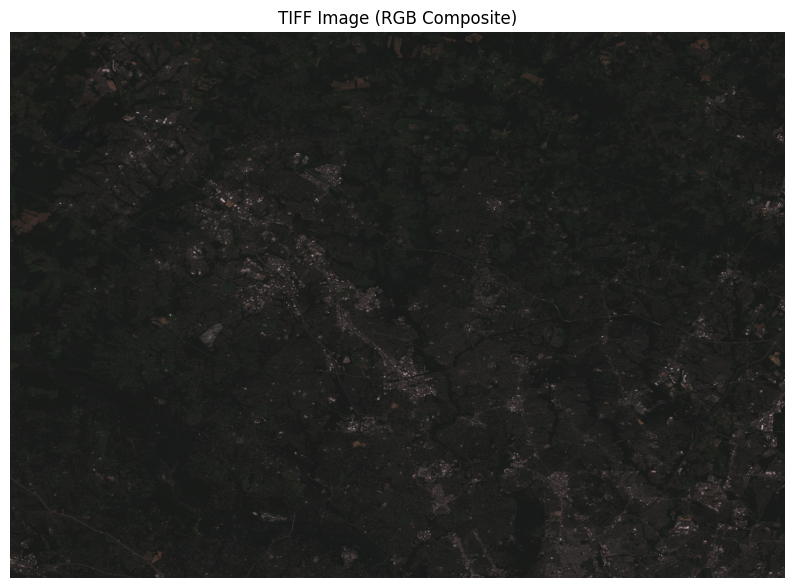

In [ ]:
tiff_path = "S2_output_IC25_enhanced.tiff"

with rasterio.open(tiff_path) as src:
    img_array = src.read()

    print("TIFF Metadata:", src.meta)
    print("Number of Bands:", img_array.shape[0])
    print("Raster Dimensions:", img_array.shape[1:]) 

    img_array = img_array.astype(np.float32)
    img_array /= np.max(img_array, axis=(1, 2), keepdims=True) 

    if img_array.shape[0] >= 3:
        rgb = np.stack([img_array[3], img_array[2], img_array[1]], axis=-1)
    else:
        raise ValueError("Not enough bands to display RGB.")

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis("off")
plt.title("TIFF Image (RGB Composite)")
plt.show()

#### **Plotting distributions for NDVI, NDWI and NDBI indices**

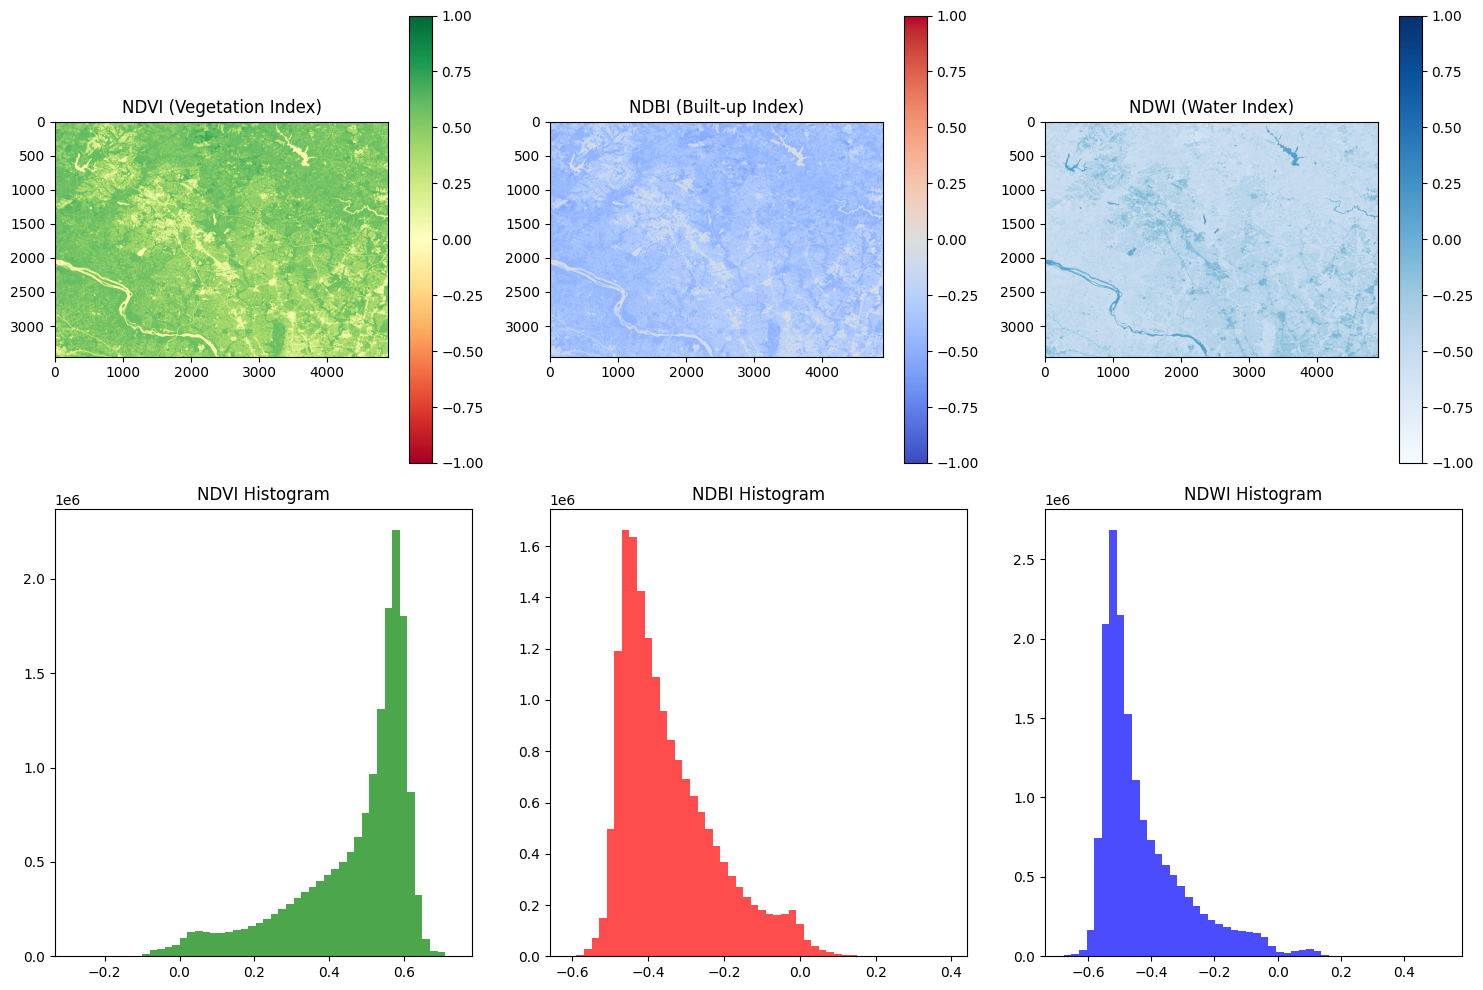

In [ ]:
tiff_path = "S2_output_IC25_enhanced.tiff" 

with rasterio.open(tiff_path) as src:
    img_array = src.read()  

red_band = img_array[3].astype(np.float32) 
nir_band = img_array[7].astype(np.float32) 
swir_band = img_array[10].astype(np.float32)
green_band = img_array[2].astype(np.float32) 

ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-8)
ndbi = (swir_band - nir_band) / (swir_band + nir_band + 1e-8)
ndwi = (green_band - nir_band) / (green_band + nir_band + 1e-8)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

im1 = axes[0, 0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0, 0].set_title("NDVI (Vegetation Index)")
fig.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(ndbi, cmap='coolwarm', vmin=-1, vmax=1)
axes[0, 1].set_title("NDBI (Built-up Index)")
fig.colorbar(im2, ax=axes[0, 1])

im3 = axes[0, 2].imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
axes[0, 2].set_title("NDWI (Water Index)")
fig.colorbar(im3, ax=axes[0, 2])

axes[1, 0].hist(ndvi.flatten(), bins=50, color='green', alpha=0.7)
axes[1, 0].set_title("NDVI Histogram")

axes[1, 1].hist(ndbi.flatten(), bins=50, color='red', alpha=0.7)
axes[1, 1].set_title("NDBI Histogram")

axes[1, 2].hist(ndwi.flatten(), bins=50, color='blue', alpha=0.7)
axes[1, 2].set_title("NDWI Histogram")

plt.tight_layout()
plt.show()


#### **Plotting the top 20 features that contribute in training the XGBoost model**

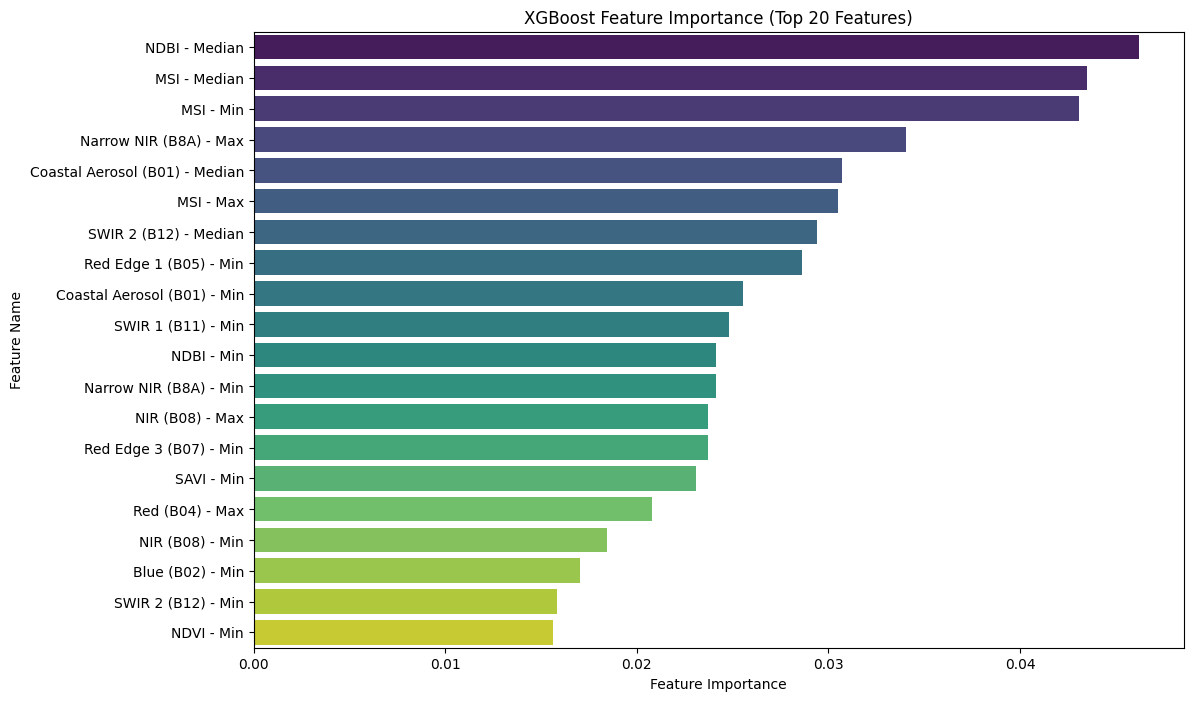

In [ ]:
np.random.seed(42)
feature_importance = model.feature_importances_  

band_labels = [
    "Coastal Aerosol (B01)", "Blue (B02)", "Green (B03)", "Red (B04)",
    "Red Edge 1 (B05)", "Red Edge 2 (B06)", "Red Edge 3 (B07)", "NIR (B08)",
    "Narrow NIR (B8A)", "SWIR 1 (B11)", "SWIR 2 (B12)",
    "NDVI", "NDBI", "NDWI", "SAVI", "MSI"
]

band_stats = ["Mean", "Std", "Min", "Max", "Median", "Range"]

feature_names = [f"{band} - {stat}" for band in band_labels for stat in band_stats]

feature_names = feature_names[:len(feature_importance)]

sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance[sorted_idx][:20], y=[feature_names[i] for i in sorted_idx][:20], palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("XGBoost Feature Importance (Top 20 Features)")
plt.show()


#### **Plotting a feature importance correlation heatmap**

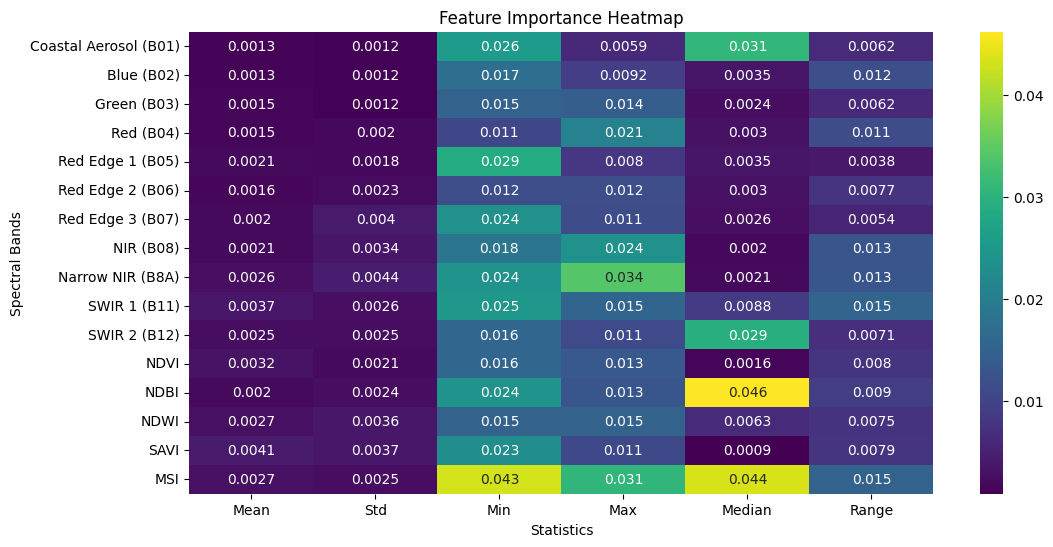

In [ ]:
feature_importance = model.feature_importances_

importance_matrix = feature_importance.reshape(len(band_labels), len(band_stats))

plt.figure(figsize=(12, 6))
sns.heatmap(importance_matrix, annot=True, cmap="viridis", xticklabels=band_stats, yticklabels=band_labels)
plt.title("Feature Importance Heatmap")
plt.xlabel("Statistics")
plt.ylabel("Spectral Bands")
plt.show()

#### **Creating an interactive heatmap with their respective UHI values present in Montgomery County, Maryland**

In [5]:
file_path = "Training_Data_IC25.csv" 
train_df = pd.read_csv(file_path)

latitude = train_df["Latitude"].values
longitude = train_df["Longitude"].values
uhi_values = train_df["UHI Index"].values 

median_uhi = np.median(uhi_values)

uhi_data = pd.DataFrame({"Latitude": latitude, "Longitude": longitude, "UHI Index": uhi_values})

map_center = [uhi_data["Latitude"].mean(), uhi_data["Longitude"].mean()]

m = folium.Map(location=map_center, zoom_start=10, tiles="cartodb dark_matter") 

heat_data = [[row["Latitude"], row["Longitude"], 1 if row["UHI Index"] > median_uhi else 0] for _, row in uhi_data.iterrows()]

HeatMap(
    heat_data, 
    min_opacity=0.7,  
    max_val=1, 
    radius=18,  
    blur=20,  
    gradient={
        0.0: "#0000FF",  
        1.0: "#FF0000"   
    }
).add_to(m)

m.save("Distinguishable_UHI_Heatmap.html")

print("Interactive heatmap saved as 'Distinguishable_UHI_Heatmap.html'. Open it in a browser to view.")


Interactive heatmap saved as 'Distinguishable_UHI_Heatmap.html'. Open it in a browser to view.


#### **Running the model for different patch sizes and plotting them against their respective r2 scores**


Evaluating Patch Size: 0
Patch Size: 0, R² Score: 0.4889

Evaluating Patch Size: 5
Patch Size: 5, R² Score: 0.8222

Evaluating Patch Size: 10
Patch Size: 10, R² Score: 0.9035

Evaluating Patch Size: 15
Patch Size: 15, R² Score: 0.9246

Evaluating Patch Size: 20
Patch Size: 20, R² Score: 0.9387

Evaluating Patch Size: 25
Patch Size: 25, R² Score: 0.9437

Evaluating Patch Size: 30
Patch Size: 30, R² Score: 0.9466

Evaluating Patch Size: 35
Patch Size: 35, R² Score: 0.9480

Evaluating Patch Size: 40
Patch Size: 40, R² Score: 0.9508

Evaluating Patch Size: 45
Patch Size: 45, R² Score: 0.9510

Evaluating Patch Size: 50
Patch Size: 50, R² Score: 0.9521


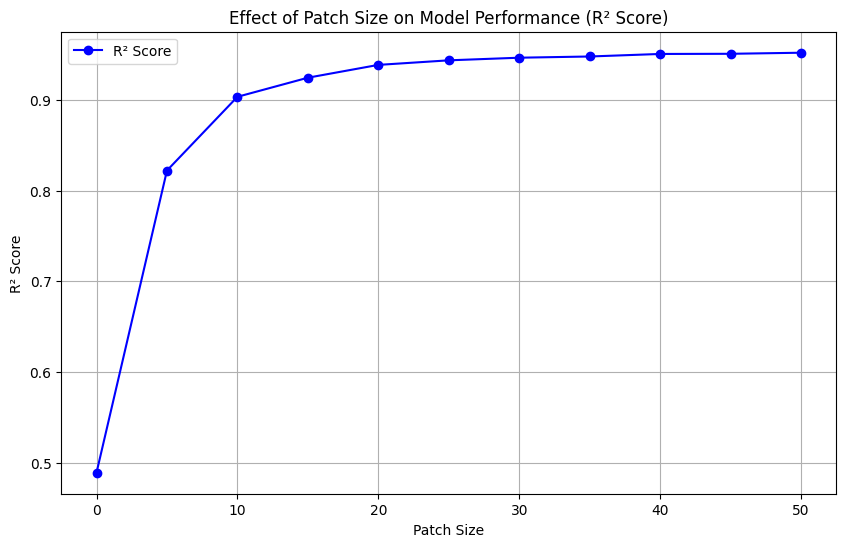

In [ ]:
train_csv = "Training_Data_IC25.csv"
tiff_path = "S2_output_IC25_enhanced.tiff"

train_df = pd.read_csv(train_csv)

train_lats = train_df["Latitude"].values
train_lons = train_df["Longitude"].values
y = train_df["UHI Index"].values

def load_tiff_as_4326(in_tiff):
    src = rasterio.open(in_tiff)
    return src

ds_4326 = load_tiff_as_4326(tiff_path)

def get_patch_stats(lat_array, lon_array, ds_4326, patch_size=5):
    n_bands = ds_4326.count
    out = np.zeros((len(lat_array), n_bands * 6), dtype=np.float32)

    for i, (lat, lon) in enumerate(zip(lat_array, lon_array)):
        try:
            row, col = ds_4326.index(lon, lat)
        except:
            continue

        row_start = row - patch_size
        col_start = col - patch_size
        window = rasterio.windows.Window.from_slices(
            (row_start, row_start + 2*patch_size + 1),
            (col_start, col_start + 2*patch_size + 1)
        )

        patch_data = ds_4326.read(window=window)

        feats = []
        for b_i in range(n_bands):
            band_arr = patch_data[b_i, :, :].astype(np.float32)
            mean_val = np.nanmean(band_arr)
            std_val  = np.nanstd(band_arr)
            min_val  = np.nanmin(band_arr)
            max_val  = np.nanmax(band_arr)
            median_val = np.nanmedian(band_arr)
            range_val  = max_val - min_val
            feats.extend([mean_val, std_val, min_val, max_val, median_val, range_val])

        out[i, :] = feats

    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out

patch_sizes = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
r2_scores = []

for patch_size in patch_sizes:
    print(f"\nEvaluating Patch Size: {patch_size}")

    train_patches = get_patch_stats(train_lats, train_lons, ds_4326, patch_size=patch_size)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(train_patches)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)
    
    model = xgb.XGBRegressor(
        n_estimators=800,  
        learning_rate=0.025,  
        max_depth=12,  
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    pred_test = model.predict(X_test)
    r2_val = r2_score(y_test, pred_test)
    r2_scores.append(r2_val)
    
    print(f"Patch Size: {patch_size}, R² Score: {r2_val:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(patch_sizes, r2_scores, marker='o', linestyle='-', color='b', label="R² Score")
plt.xlabel("Patch Size")
plt.ylabel("R² Score")
plt.title("Effect of Patch Size on Model Performance (R² Score)")
plt.legend()
plt.grid(True)
plt.show()
